Classification is the task of categorizing the known classes based on their features. In most classification problems, machine learning algorithms will do the job, but while classifying a large dataset of images, you will need to use a neural network.

In [3]:
#Importing the required libraries
import numpy as np # linear algebra
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
fashion_data = keras.datasets.fashion_mnist

In [6]:
(xtrain,ytrain), (xtest,ytest) = fashion_data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's take a sneak peek into the dataset

Image Label : 0


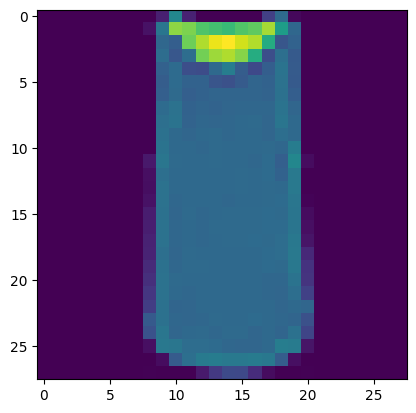

In [21]:
imgIndex = 2
image = xtrain[imgIndex]
print('Image Label :', ytrain[imgIndex])
plt.imshow(image);

Let's check the shape of the dataset

In [23]:
print(xtrain.shape)
print(xtest.shape)

(60000, 28, 28)
(10000, 28, 28)


# Building a Neutral Network

In [24]:
model = keras.models.Sequential(
    [keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(300, activation = 'relu'),
    keras.layers.Dense(100, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax')]
)

print(model.summary())

2025-04-30 22:35:48.951292: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
#Splitting the dataset into training and validation set
xvalid,xtrain = xtrain[:5000]/255.0, xtrain[5000:]/255.0
yvalid, ytrain = ytrain[:5000], ytrain[5000:]

# Training a classification model with Neural Networks

In [27]:
#setting the loss function, optimizer and evaluation metric
model.compile(loss = 'sparse_categorical_crossentropy', optimizer ='adam', metrics = ['accuracy'] )
#fitting the dataset in the model
history = model.fit(xtrain,ytrain, epochs = 30 , validation_data = (xvalid, yvalid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7806 - loss: 0.6159 - val_accuracy: 0.8486 - val_loss: 0.3947
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8610 - loss: 0.3727 - val_accuracy: 0.8682 - val_loss: 0.3505
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8801 - loss: 0.3261 - val_accuracy: 0.8816 - val_loss: 0.3219
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8877 - loss: 0.3056 - val_accuracy: 0.8870 - val_loss: 0.3134
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8947 - loss: 0.2802 - val_accuracy: 0.8854 - val_loss: 0.3118
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9007 - loss: 0.2647 - val_accuracy: 0.8862 - val_loss: 0.3121
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9033 - loss: 0.2525 - val_accuracy: 0.8944 - val_loss: 0.2962
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9037 - loss: 0.2517 - 

# Time to predict

In [33]:
new = xtest[:7]
prediction = model.predict(new)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [34]:
label_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

In [36]:
# raw numeric predictions and truths
y_pred = np.argmax(model.predict(xtest), axis=1)

print("First 10 true labels:     ", ytest[:30])
print("First 10 predicted labels:", y_pred[:30])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
First 10 true labels:      [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3]
First 10 predicted labels: [9 2 1 1 6 1 4 6 5 7 4 5 5 3 4 1 2 4 8 0 2 5 7 5 1 4 6 0 9 4]


In [37]:
for true_i, pred_i in zip(ytest[:5], y_pred[:5]):
    print("True:",  label_names[true_i].ljust(12),
          " Pred:", label_names[pred_i])


True: Ankle boot    Pred: Ankle boot
True: Pullover      Pred: Pullover
True: Trouser       Pred: Trouser
True: Trouser       Pred: Trouser
True: Shirt         Pred: Shirt


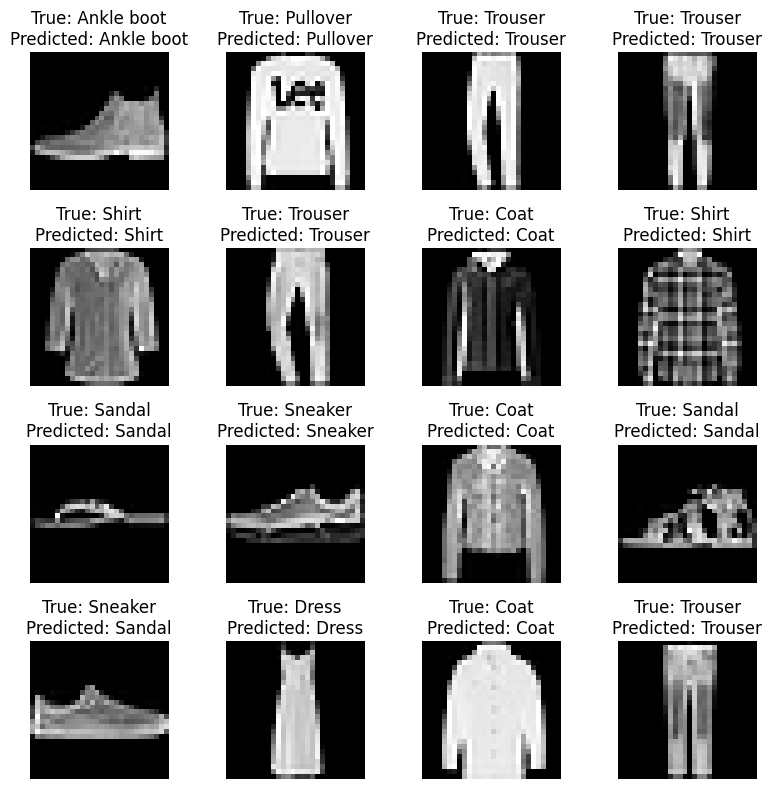

In [41]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(xtest[i], cmap='gray')
    plt.title(f"True: {label_names[ytest[i]]}\nPredicted: {label_names[y_pred[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# Summary
Classification is the task of categorizing the known classes based on their features. In most classification problems, machine learning algorithms will do the job, but while classifying a large dataset of images, you will need to use a neural network.